In [7]:
from __future__ import annotations

import os
import asyncio
from contextlib import asynccontextmanager
from datetime import UTC, datetime
from pathlib import Path
from typing import Any


from src.streetparade_embeddings.user_visualization import recompute_layout as _recompute_layout

In [13]:

from src.streetparade_embeddings.db import init_db
from src.streetparade_embeddings.user_visualization import get_or_create_user as _get_or_create_user

In [17]:
init_db
_get_or_create_user("harry")

{'id': 3,
 'uuid': '945682db98794dd0875ce2fb7e3e2d03',
 'username': 'harry',
 'created_at': '2026-08-02T07:31:29.873960+00:00',
 'updated_at': '2026-08-02T07:31:40.883859+00:00'}

In [35]:
from src.streetparade_embeddings.user_visualization import vectors_for_rows, rows_with_vectors, latest_embedding_rows
rows = latest_embedding_rows(include_user_artists=False)
pairs = rows_with_vectors(rows)
# from src.streetparade_embeddings.vectorstore import get_vector_store

In [46]:
from sklearn.manifold import TSNE
import numpy as np
res = np.vstack([v for _,  v in pairs])
t = TSNE().fit_transform(res)

In [ ]:
from sklearn.cluster import SpectralClustering

In [52]:
cl = SpectralClustering(n_clusters=8).fit_predict(res_pca)

In [58]:
from sklearn.decomposition import PCA
res_pca = PCA(n_components=20).fit_transform(res)
t_pca = TSNE(metric='cosine').fit_transform(res_pca)

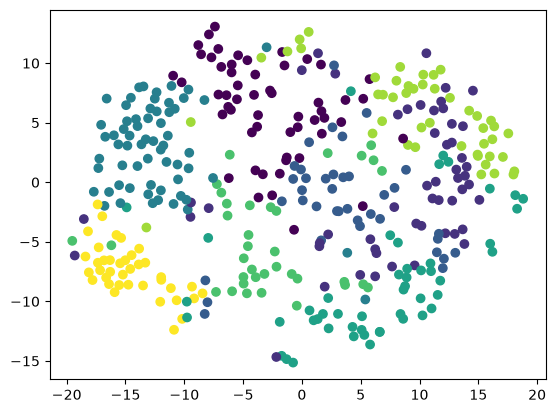

In [59]:
import matplotlib.pyplot as pplot
pplot.scatter(*t_pca.T, c=cl)

In [27]:
VECTORSTORE_PATH = 'chroma'
vs = get_vector_store(VECTORSTORE_PATH)



In [ ]:
coll = vs.collection

Collection(id=UUID('aaf237e4-b6b9-4370-941a-c28b7ade50b8'), name='track_embeddings', configuration_json={'hnsw': {'space': 'cosine', 'ef_construction': 100, 'ef_search': 100, 'max_neighbors': 16, 'resize_factor': 1.2, 'sync_threshold': 1000}, 'spann': None, 'embedding_function': {'type': 'known', 'name': 'default', 'config': {}}}, serialized_schema={'defaults': {'string': {'fts_index': {'enabled': False, 'config': {}}, 'string_inverted_index': {'enabled': True, 'config': {}}}, 'float_list': {'vector_index': {'enabled': False, 'config': {'space': 'cosine', 'embedding_function': {'type': 'known', 'name': 'default', 'config': {}}, 'hnsw': {'ef_construction': 100, 'max_neighbors': 16, 'ef_search': 100, 'num_threads': 24, 'batch_size': 100, 'sync_threshold': 1000, 'resize_factor': 1.2}}}}, 'sparse_vector': {'sparse_vector_index': {'enabled': False, 'config': {'embedding_function': {'type': 'unknown'}, 'bm25': False}}}, 'int': {'int_inverted_index': {'enabled': True, 'config': {}}}, 'float':